# CosmoFit — CPL (w0waCDM) MCMC Analysis (4-dataset, publication-quality)

This notebook is an end-to-end walkthrough of **CosmoFit**: fitting the
**CPL (Chevallier–Polarski–Linder) dark-energy model**,

$$w(z) = w_0 + w_a \frac{z}{1+z},$$

to real cosmological data — Cosmic Chronometers, DESI BAO, Pantheon+
supernovae, **and Planck's CMB distance priors** — in a single joint
MCMC fit, with a long, publication-quality chain, convergence
diagnostics, the standard publication-style figures, and a model
comparison against flat $\Lambda$CDM.

This is a longer-running variant of `cpl_mcmc_analysis.ipynb`: adding
Planck breaks the $H_0$–$\Omega_m$–$r_d$ geometric degeneracy that a
late-time-only (CC+DESI+Pantheon) fit can't resolve on its own, which
is what lets $r_d$ and $\Omega_b$ join the free parameters here instead
of being held fixed -- see section 3. The MCMC settings are also pushed
well past "a few minutes" (`nwalkers=64`, `nsteps=12000`) for a
publication-grade chain, evaluated across every CPU core available
(section 4) since a single-core chain this long would take a long time.

**Running this notebook:** open it in Google Colab and choose
*Runtime → Run all*. The first cell installs CosmoFit and its
dependencies; everything after that just works. Locally, it assumes
CosmoFit is already installed (`pip install -e .` from the repository
root).

**Runtime:** the MCMC cells are CPU-bound and, even parallelized across
all cores, take on the order of 15-30 minutes total (highly
machine-dependent -- Colab's free tier typically gives you 2 cores,
so expect longer there than on a many-core workstation).


## 1. Setup

Installs CosmoFit + dependencies when running in Google Colab. If you're running this locally from a cloned repository with CosmoFit already installed (`pip install -e .`), this cell does nothing.

In [1]:
import sys, os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    if not os.path.exists("CosmoFit"):
        !git clone --quiet -b dev https://github.com/salihyesil59/CosmoFit.git
    %cd CosmoFit
    !pip install -q -e .
else:
    print("Not running in Colab -- assuming CosmoFit is already installed "
          "(pip install -e . from the repository root).")


Not running in Colab -- assuming CosmoFit is already installed (pip install -e . from the repository root).


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from CosmoFit import LCDM, CPL, Fitter
from CosmoFit.stats import model_comparison, cpl_diagnostics
from CosmoFit.data.loader import available_datasets

%matplotlib inline
plt.rcParams["figure.dpi"] = 110
np.random.seed(0)


## 2. Datasets

CosmoFit ships with four built-in observational datasets, and this
notebook uses all of them: Cosmic Chronometers, DESI BAO, and
Pantheon+ (the late-time, purely background-expansion probes), plus
Planck's compressed CMB distance priors ($R$, $\ell_A$,
$\omega_b h^2$) -- included directly in the joint fit this time,
rather than as a separate independent check (compare with
`cpl_mcmc_analysis.ipynb`, which keeps them separate).

In [3]:
available_datasets()

{'cc': ['favale2023'],
 'desi': ['desi2024'],
 'sdss_bao': ['dr12+dr16'],
 'pantheon': ['pantheon+sh0es'],
 'des_sn5yr': ['des-sn5yr'],
 'planck': ['planck2018']}

## 3. Building the CPL fit

Free parameters: $H_0$, $\Omega_m$, $w_0$, $w_a$, $r_d$, $\Omega_b$.

With only CC+DESI+Pantheon, $r_d$ can't be separated from $H_0$ in the
BAO distance ratios ($D_M/r_d$, etc.) without an independent handle on
the absolute distance scale -- that's why `cpl_mcmc_analysis.ipynb`
holds it fixed. Planck's $R$ and $\ell_A$ provide exactly that handle
(they pin down $H_0 \cdot D_M(z_*)$ and $D_M(z_*)/r_s(z_*)$
directly), so with Planck in the fit $r_d$ becomes constrainable and
joins the free parameters -- the standard approach in the DESI 2024
CPL papers this reproduces the spirit of.

$\Omega_b$ joins them too: Planck's $\omega_b h^2$ data point
constrains it directly, and holding $\Omega_b$ fixed while still
scoring the fit against that data point would let its constraining
power leak entirely into $H_0$ instead of being properly marginalized
over its own uncertainty.

In [4]:
fit = Fitter(
    model=CPL,
    datasets=["cc", "desi", "pantheon", "planck"],
    free_params=["H0", "Omega_m", "w0", "wa", "rd", "Omega_b"],
    initial={
        "H0": 67.4,
        "Omega_m": 0.315,
        "w0": -1.0,
        "wa": 0.0,
        "rd": 147.1,
        "Omega_b": 0.0493,
    },
)

fit

Fitter(model=CPL, datasets=['cc', 'desi', 'pantheon', 'planck'], free_params=['H0', 'Omega_m', 'w0', 'wa', 'rd', 'Omega_b'])

In [5]:
print(f"Total data points: {fit.n_data}")
fit.chi2_breakdown()

Total data points: 1671


{'CC': 13.3377083716049,
 'DESI': 20.712473590731655,
 'Pantheon+': 1457.4988513663411,
 'Planck': 98.61739166768078}

## 4. Running the MCMC

`Fitter.run_mcmc` wraps `emcee.EnsembleSampler`. For a publication-
quality chain we push well past the "few minutes" demo settings:
`nwalkers=64` (comfortably above the `>= 2 * ndim = 12` emcee needs,
enough for healthy mixing across 6 free parameters) and
`nsteps=12000`. Check `fit.convergence()` in the next section before
trusting the result -- if `converged` comes back `False`, that means
this chain wasn't long enough yet and `nsteps` needs to go higher
still (there's no way to know the required length ahead of time; it
depends on how correlated the actual posterior turns out to be).

`n_processes` evaluates the ensemble's walkers across multiple CPU
cores instead of one (`os.cpu_count()` here -- every core available).
This is a real speedup (~2-2.5x measured on an 8-core machine for
this exact 4-dataset fit) but well under `n_processes`x, since
splitting the work across processes has its own overhead -- see
`Fitter.run_mcmc`'s docstring for how it's implemented (each worker
process builds its own `Fitter` once, rather than the naive approach
of repeatedly shipping the whole likelihood -- Pantheon+'s covariance
matrix alone -- to every worker on every step, which measured
*slower* than a single process). Only works for built-in models like
`CPL` here (not a `define_model()` custom model), and is most
reliable on Linux/macOS -- see the docstring for why.

In [6]:
fit.run_mcmc(
    nwalkers=64, nsteps=12000, burnin=2000, seed=42,
    progress=True, n_processes=os.cpu_count(),
)

100%|██████████| 12000/12000 [11:11<00:00, 17.87it/s]


## 5. Convergence diagnostics

Before trusting any posterior summary or figure below, check that the
chain has actually mixed: the integrated autocorrelation time $\tau$
should be much shorter than the chain length (`converged=True` requires
at least 50$\tau$, `emcee`'s own recommended rule of thumb). Short demo
runs like this one often fall a little short of that -- rerun with more
steps if `converged` is `False` and you need publication-quality
intervals.

In [7]:
conv = fit.convergence()

for name, tau in conv["tau"].items():
    print(f"{name:>10s}:  tau = {tau:6.1f}   n_eff = {conv['n_effective'][name]:7.1f}")

print(f"\nconverged (n_steps >= 50*tau for every parameter): {conv['converged']}")

        H0:  tau =   73.5   n_eff =  8704.1
   Omega_m:  tau =   66.9   n_eff =  9560.3
        w0:  tau =   75.9   n_eff =  8427.9
        wa:  tau =   86.2   n_eff =  7420.6
        rd:  tau =   69.7   n_eff =  9178.4
   Omega_b:  tau =   77.4   n_eff =  8268.3

converged (n_steps >= 50*tau for every parameter): True


## 6. Posterior summary and best fit

In [8]:
for name, stats_ in fit.summary().items():
    print(f"{name:>10s} = {stats_['median']:8.4f}  "
          f"+{stats_['plus']:.4f} / -{stats_['minus']:.4f}")

        H0 =  67.9459  +0.7666 / -0.7527
   Omega_m =   0.3139  +0.0078 / -0.0077
        w0 =  -0.8473  +0.0698 / -0.0684
        wa =  -0.6344  +0.3013 / -0.3286
        rd = 147.1844  +0.8608 / -0.8385
   Omega_b =   0.0484  +0.0011 / -0.0011


In [9]:
result = fit.best_fit()

print("Best-fit parameters (maximum likelihood):")
for name, value in fit.best_fit_params.items():
    print(f"  {name:>10s} = {value:.4f}")

print(f"\nchi2_min = {fit.best_fit_chi2:.2f}  "
      f"({fit.n_data} data points, {fit.ndim} free parameters)")

Best-fit parameters (maximum likelihood):
          H0 = 67.9606
     Omega_m = 0.3135
          w0 = -0.8504
          wa = -0.6158
          rd = 147.2196
     Omega_b = 0.0484

chi2_min = 1480.78  (1671 data points, 6 free parameters)


## 7. MCMC diagnostics: chain trace and corner plot

Every plot in CosmoFit lives on `fit.plots` (a `plots.FitPlotter`
instance).

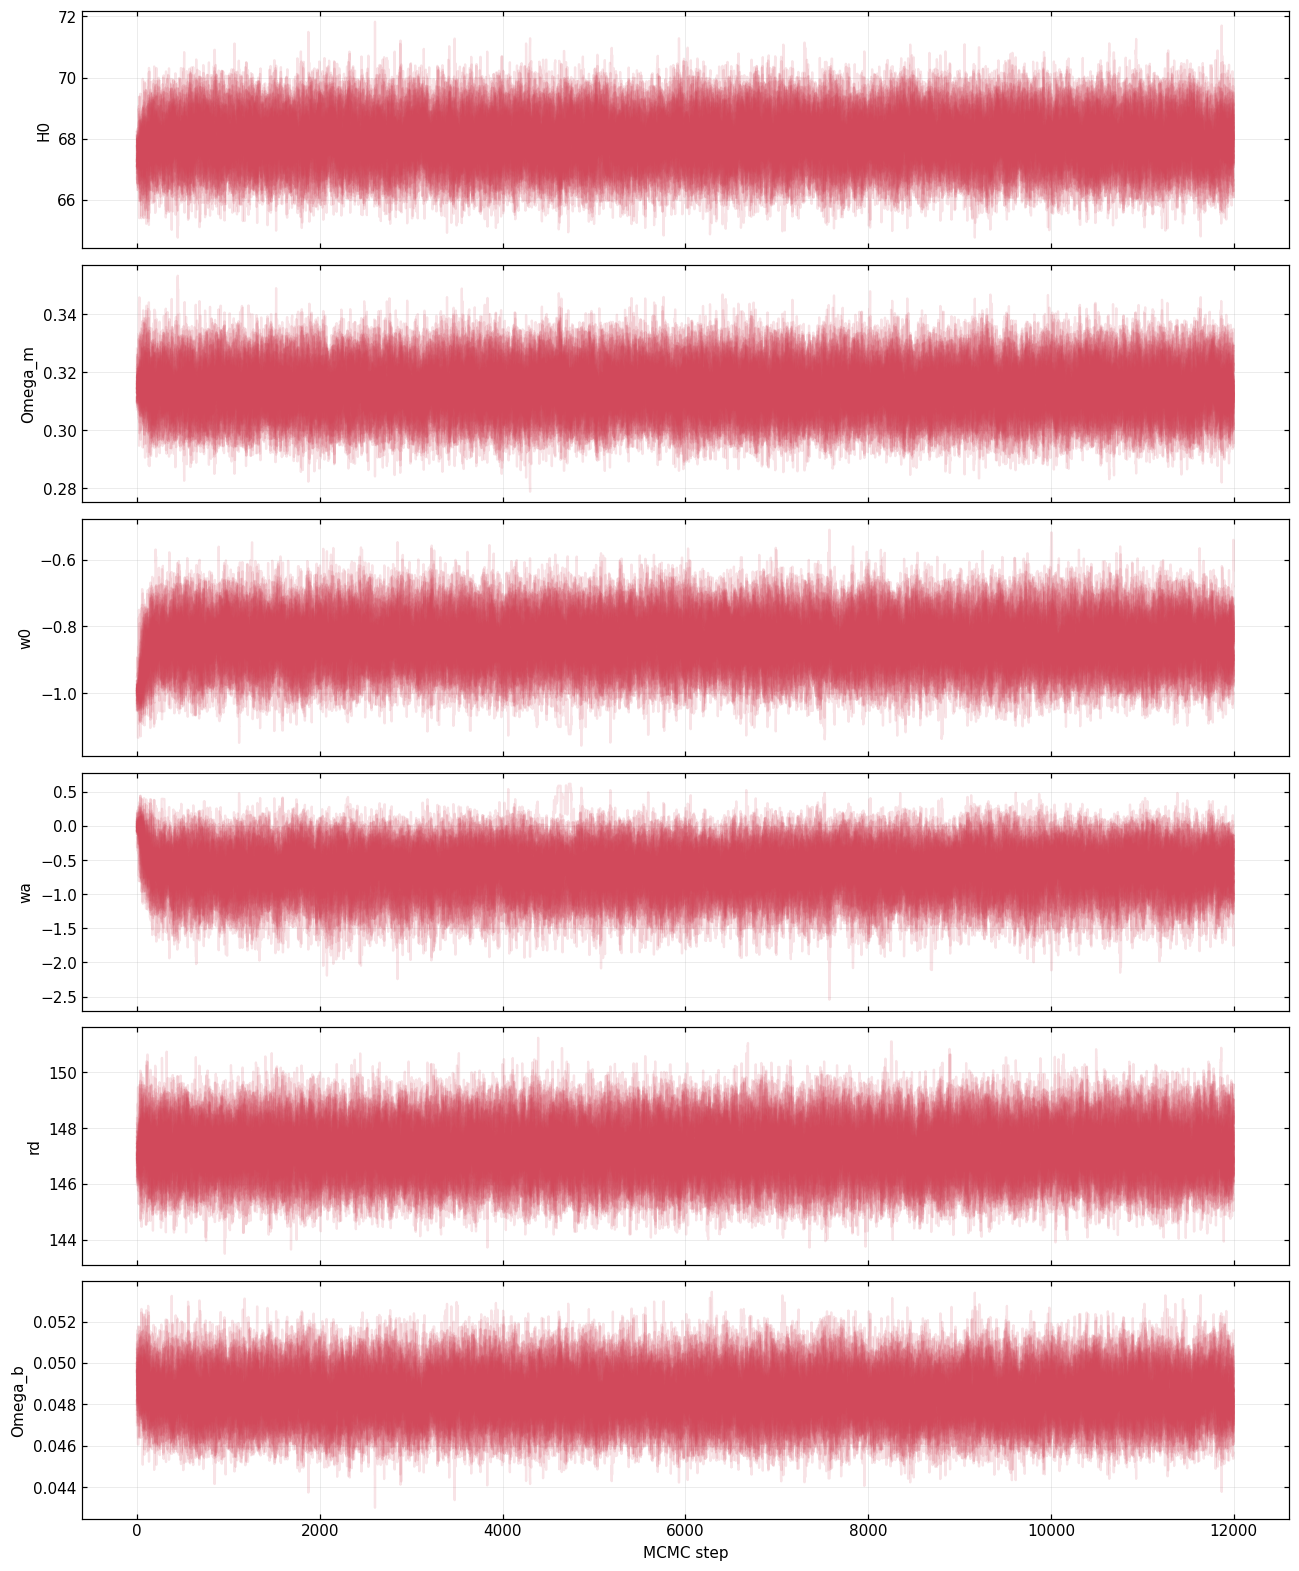

In [10]:
fig = fit.plots.chain()

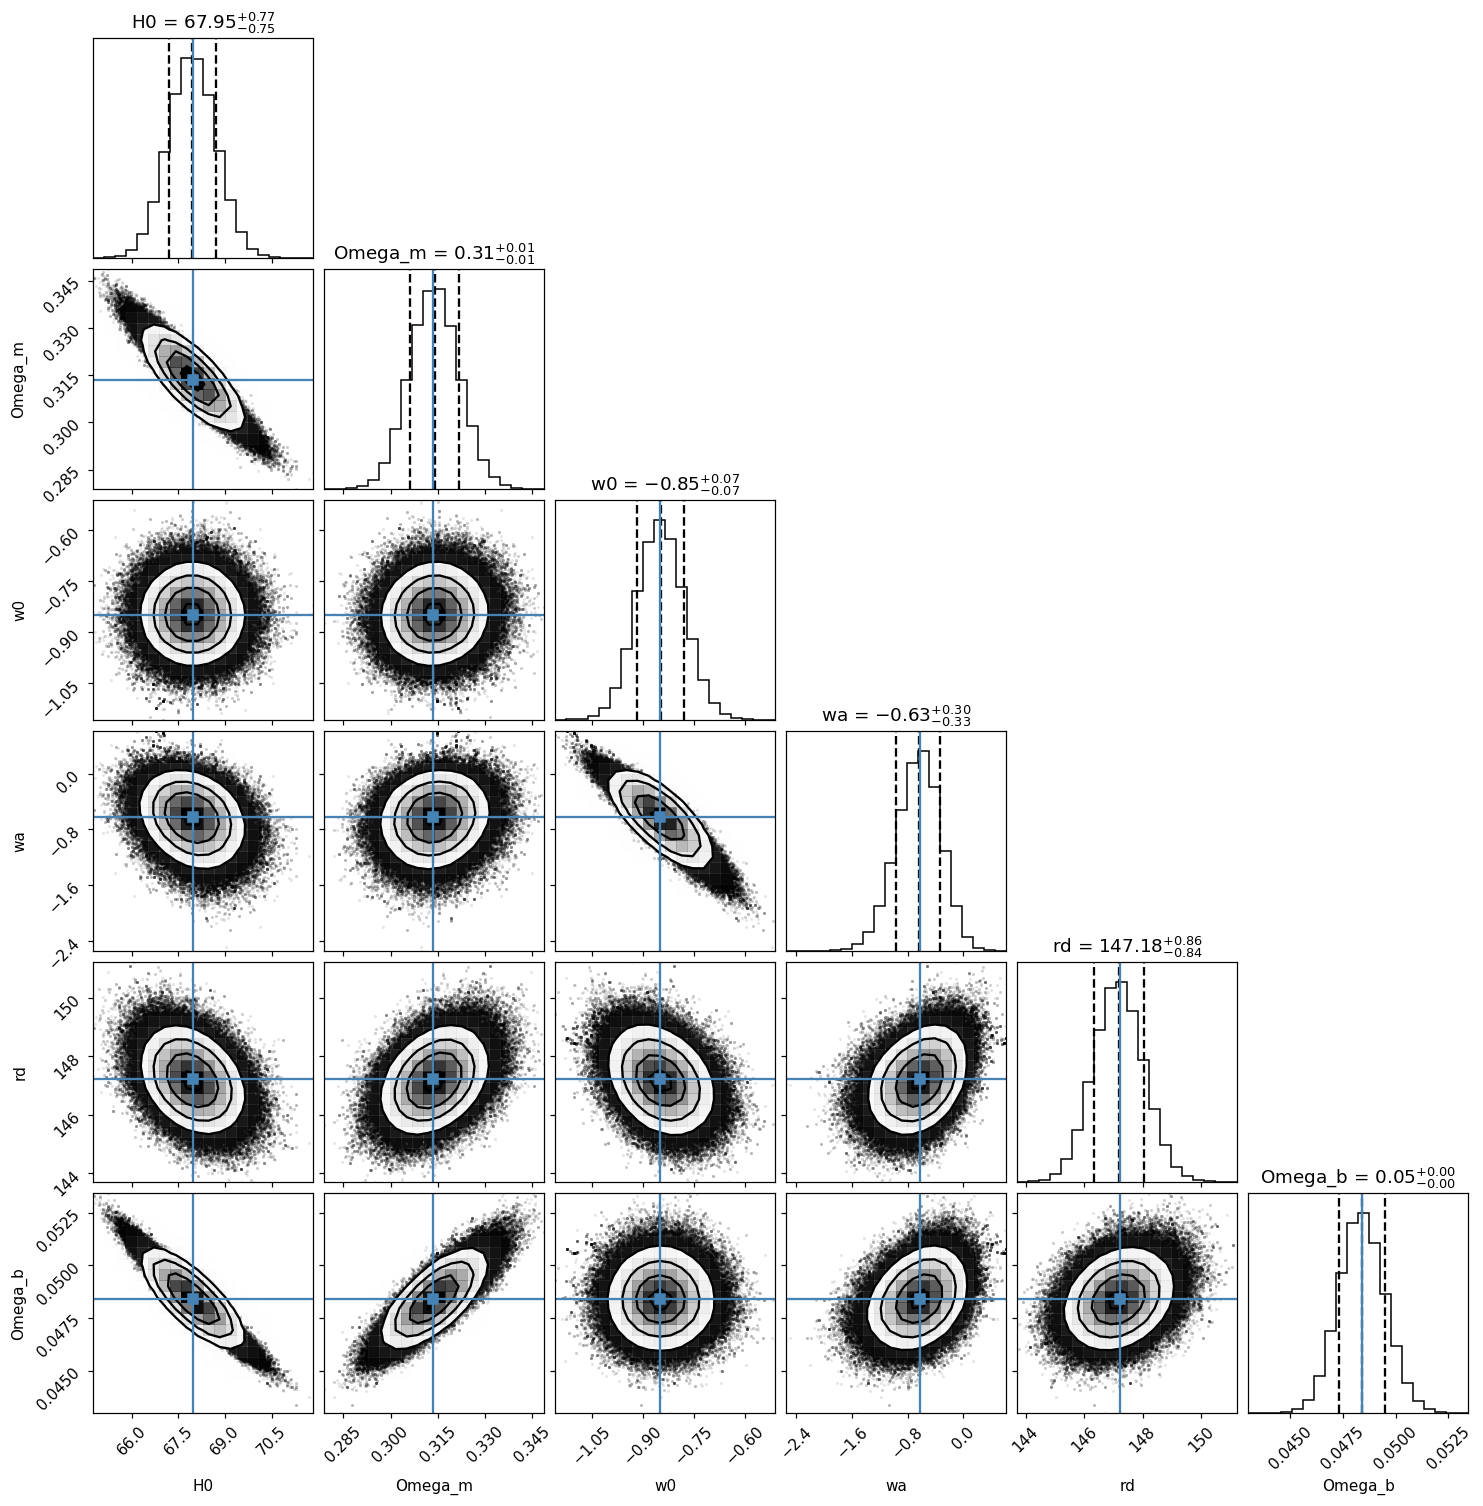

In [11]:
fig = fit.plots.corner(truths=[
    fit.best_fit_params["H0"],
    fit.best_fit_params["Omega_m"],
    fit.best_fit_params["w0"],
    fit.best_fit_params["wa"],
    fit.best_fit_params["rd"],
    fit.best_fit_params["Omega_b"],
])

## 8. Data vs. model: the standard cosmology figures

Each figure below shows the data against the model evaluated at the
posterior median, with a shaded 68% posterior-predictive band built from
random draws of the MCMC chain (not just a single best-fit curve).

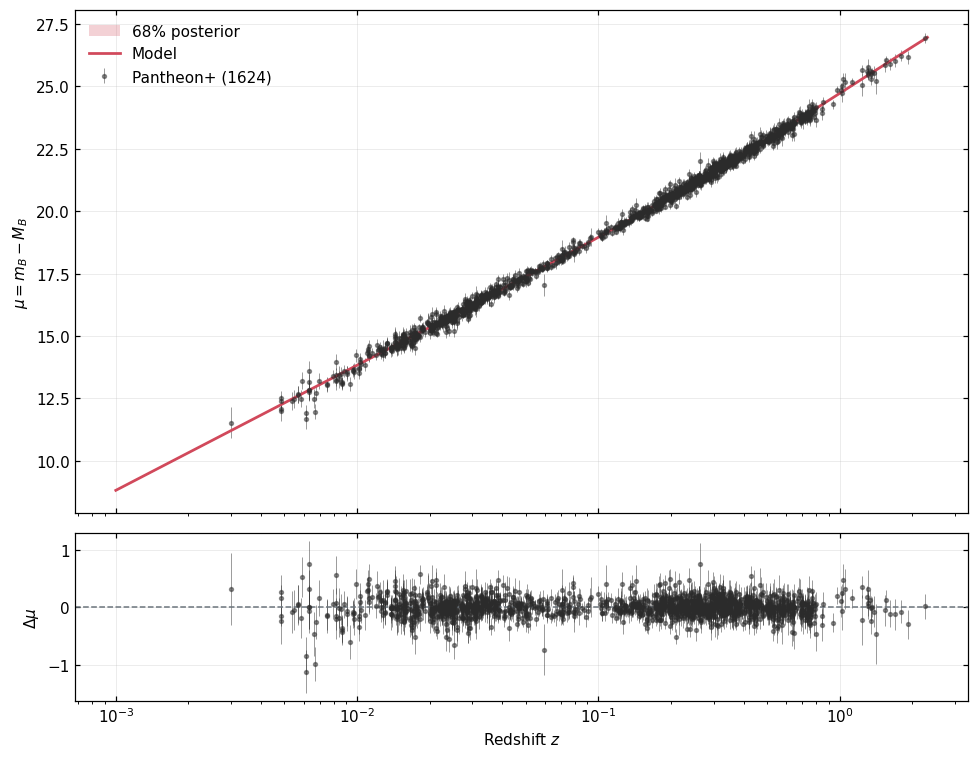

In [12]:
fig = fit.plots.hubble_diagram()

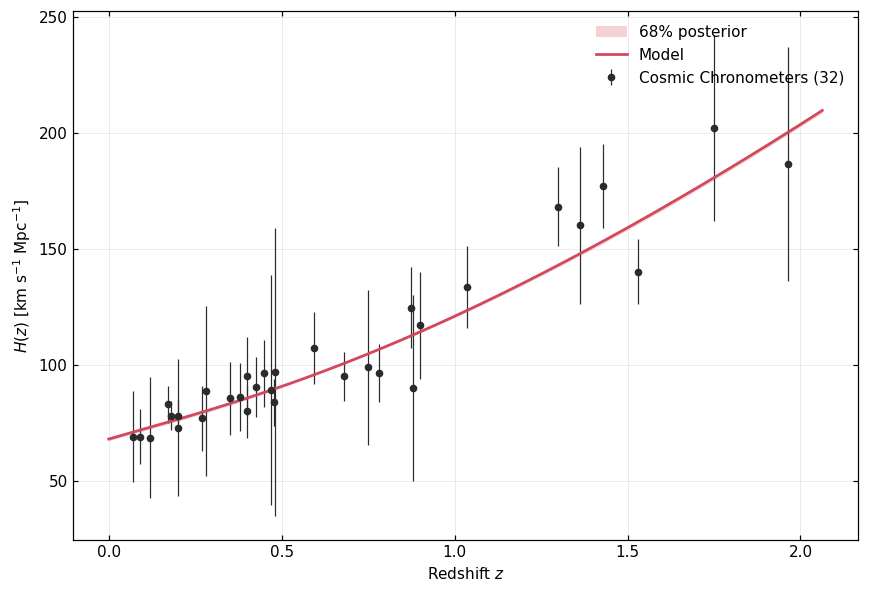

In [13]:
fig = fit.plots.hz()

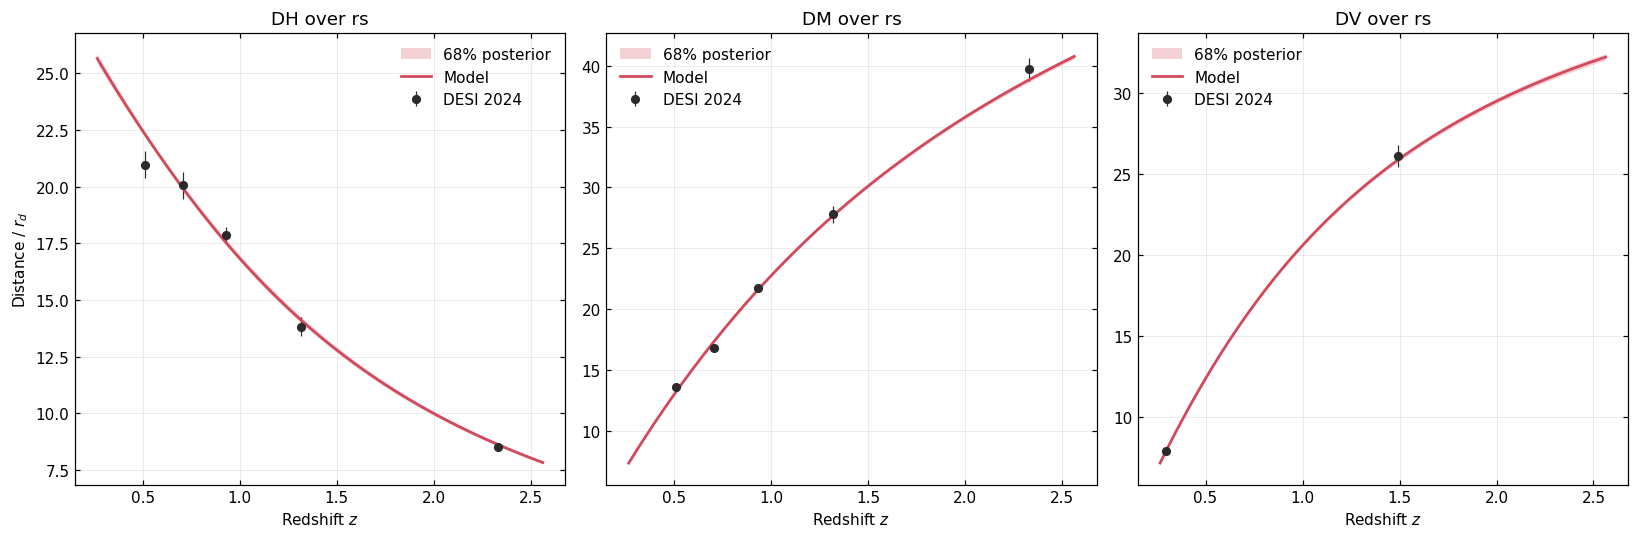

In [14]:
fig = fit.plots.bao_distances()

## 9. Dark-energy equation of state $w(z)$ and the deceleration parameter

CPL's whole point is letting $w(z)$ evolve. The plot below shows the
posterior band for $w(z)$ against the $\Lambda$CDM reference line
$w=-1$, with any $w(z){=}{-1}$ crossing redshifts marked -- and the
deceleration parameter $q(z)$, with the deceleration/acceleration
transition redshift $z_t$ (where $q(z_t)=0$) marked.

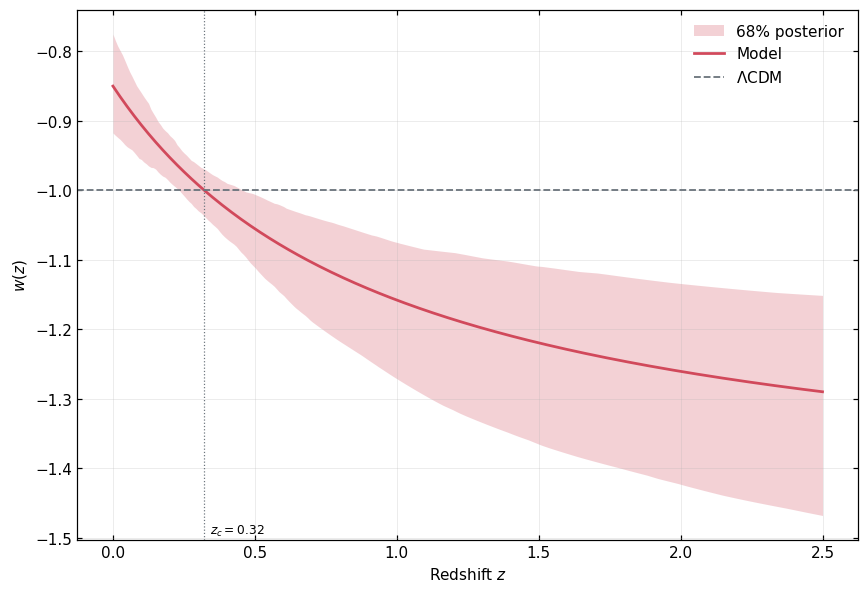

In [15]:
fig = fit.plots.w_of_z()

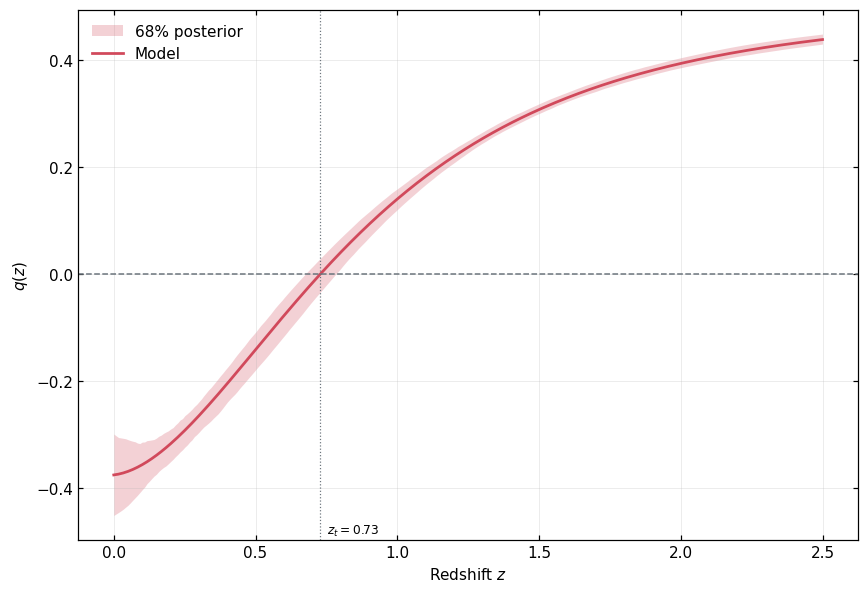

In [16]:
fig = fit.plots.deceleration()

### CPL-specific posterior diagnostics

`stats.cpl_diagnostics` turns the $(w_0, w_a)$ posterior into the
quantities dark-energy papers usually quote: the $w(z)=-1$ crossing
redshift distribution, its direction (quintessence-like $\to$
phantom-like or the reverse), and how many "sigma" away the $\Lambda$CDM
point $(w_0, w_a) = (-1, 0)$ sits from the 2D posterior.

In [17]:
samples = fit.samples_dict()

z_cross, frac_cross = cpl_diagnostics.crossing_redshift(samples["w0"], samples["wa"])
print(f"w(z)=-1 crossing: {frac_cross:.1%} of samples cross in [0, 2.5], "
      f"at z = {np.median(z_cross):.2f} (median) if they do")

if len(z_cross) > 0:
    direction = cpl_diagnostics.crossing_direction(samples["w0"], samples["wa"])
    print(f"  quintessence -> phantom: {direction['quintessence_to_phantom']:.1%}")
    print(f"  phantom -> quintessence: {direction['phantom_to_quintessence']:.1%}")

lcdm_distance = cpl_diagnostics.mahalanobis_from_lcdm(samples["w0"], samples["wa"])
print(f"\nLCDM point (w0, wa) = (-1, 0) is "
      f"{lcdm_distance['distance']:.2f} sigma from the CPL posterior mean "
      f"{tuple(np.round(lcdm_distance['mean'], 3))}")

w(z)=-1 crossing: 97.9% of samples cross in [0, 2.5], at z = 0.31 (median) if they do
  quintessence -> phantom: 99.2%
  phantom -> quintessence: 0.8%

LCDM point (w0, wa) = (-1, 0) is 2.20 sigma from the CPL posterior mean (np.float64(-0.847), np.float64(-0.647))


## 10. Model comparison: CPL vs. flat $\Lambda$CDM

Is the extra freedom of CPL ($w_0$, $w_a$) actually preferred by the
data over flat $\Lambda$CDM, once model complexity is penalized? Fit
$\Lambda$CDM to the *same* four datasets -- with the *same* other free
parameters ($H_0$, $\Omega_m$, $r_d$, $\Omega_b$), so it's genuinely
CPL's nested special case at $w_0=-1,\ w_a=0$ and not a smaller,
differently-configured fit -- and compare with AIC, BIC, and a
likelihood-ratio test.

In [18]:
fit_lcdm = Fitter(
    model=LCDM,
    datasets=["cc", "desi", "pantheon", "planck"],
    free_params=["H0", "Omega_m", "rd", "Omega_b"],
    initial={"H0": 67.4, "Omega_m": 0.315, "rd": 147.1, "Omega_b": 0.0493},
)

fit_lcdm.run_mcmc(
    nwalkers=32, nsteps=8000, burnin=1500, seed=42,
    progress=True, n_processes=os.cpu_count(),
)
fit_lcdm.best_fit()

print(f"LCDM  chi2_min = {fit_lcdm.best_fit_chi2:.2f}  ({fit_lcdm.ndim} free parameters)")
print(f"CPL   chi2_min = {fit.best_fit_chi2:.2f}  ({fit.ndim} free parameters)")

100%|██████████| 8000/8000 [03:58<00:00, 33.50it/s]


LCDM  chi2_min = 1485.45  (4 free parameters)
CPL   chi2_min = 1480.78  (6 free parameters)


In [19]:
comparison = model_comparison.compare_models(
    name_null="LCDM",
    chi2_null=fit_lcdm.best_fit_chi2,
    k_null=fit_lcdm.ndim,
    name_alt="CPL",
    chi2_alt=fit.best_fit_chi2,
    k_alt=fit.ndim,
    n_data=fit.n_data,
)

for name in ("LCDM", "CPL"):
    row = comparison[name]
    print(f"{name:>5s}:  chi2={row['chi2']:8.2f}   AIC={row['AIC']:8.2f}   BIC={row['BIC']:8.2f}")

print(f"\ndelta_AIC (LCDM - CPL) = {comparison['delta_AIC']:+.2f}   "
      f"(positive favors CPL)")
print(f"delta_BIC (LCDM - CPL) = {comparison['delta_BIC']:+.2f}   "
      f"(BIC penalizes extra parameters more strongly than AIC)")

lrt = comparison["likelihood_ratio_test"]
print(f"\nLikelihood-ratio test: delta_chi2={lrt['delta_chi2']:.2f} "
      f"(delta_k={lrt['delta_k']}), p={lrt['p_value']:.3f}, "
      f"{lrt['sigma']:.2f} sigma preference for CPL over LCDM")

 LCDM:  chi2= 1485.45   AIC= 1493.45   BIC= 1515.13
  CPL:  chi2= 1480.78   AIC= 1492.78   BIC= 1525.30

delta_AIC (LCDM - CPL) = +0.67   (positive favors CPL)
delta_BIC (LCDM - CPL) = -10.17   (BIC penalizes extra parameters more strongly than AIC)

Likelihood-ratio test: delta_chi2=4.67 (delta_k=2), p=0.097, 1.30 sigma preference for CPL over LCDM


A modest AIC/BIC improvement or a low-significance likelihood-ratio
result here is not a discovery of evolving dark energy -- it just means
the data don't yet strongly prefer one model over the other. Unlike
`cpl_mcmc_analysis.ipynb`, Planck is now part of the joint fit itself
(not a separate check), which is closer to how DESI's own 2024 CPL
analysis is actually done -- combining BAO with CMB and SN
compilations, where a few-sigma preference for evolving dark energy
shows up in some dataset combinations.

## 11. CPL vs. flat $\Lambda$CDM: side-by-side comparison plots

The AIC/BIC/likelihood-ratio numbers above say *whether* CPL is
statistically preferred; these figures show *what that difference
actually looks like*. Every `fit.plots.*` figure has a `compare_*`
counterpart that overlays this fit's curve with one or more other
models' curves on the same data/axes -- `fit.plots.compare_hz(other_fits=fit_lcdm)`
here, since `fit_lcdm` was already built and MCMC-fit above for the
model-comparison section. (Left on its own, `compare_hz()` etc. would
auto-build a quick best-fit-only $\Lambda$CDM reference for exactly
this comparison -- passing `fit_lcdm` explicitly just reuses the full
MCMC posterior we already have instead.) This works for any model
CosmoFit knows about (built-in or [custom](https://github.com/salihyesil59/CosmoFit#custom-models)),
and for more than two at once via `other_fits=[fit_a, fit_b, ...]`.

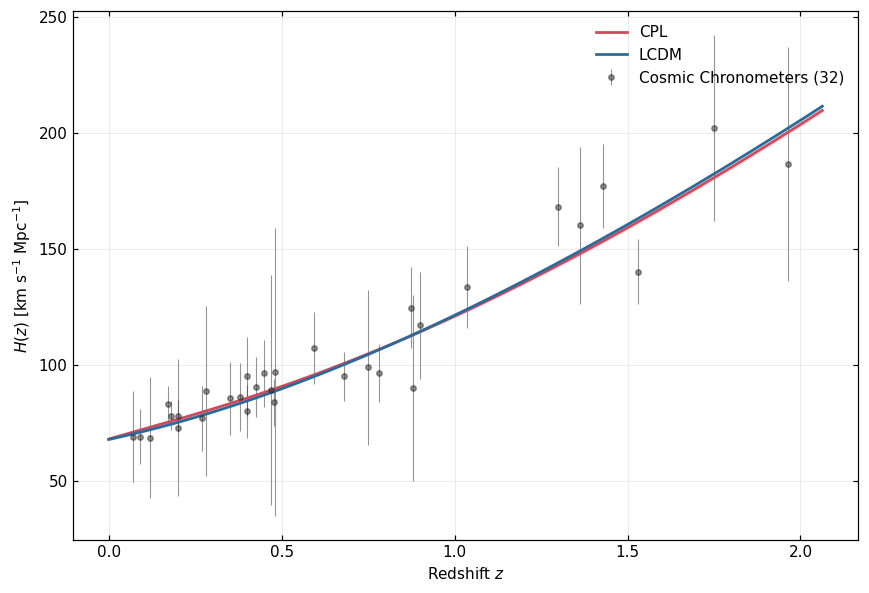

In [20]:
fig = fit.plots.compare_hz(other_fits=fit_lcdm, labels=["CPL", "LCDM"])

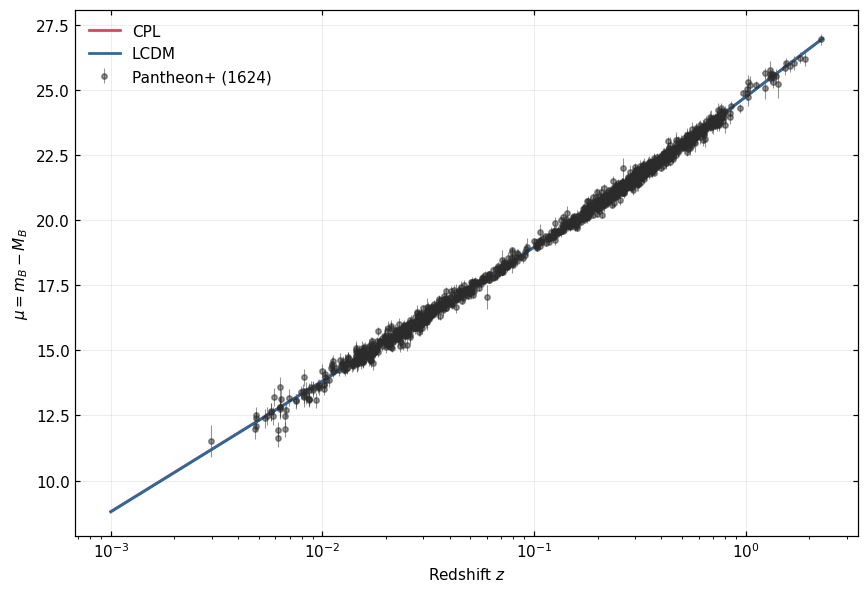

In [21]:
fig = fit.plots.compare_hubble_diagram(other_fits=fit_lcdm, labels=["CPL", "LCDM"])

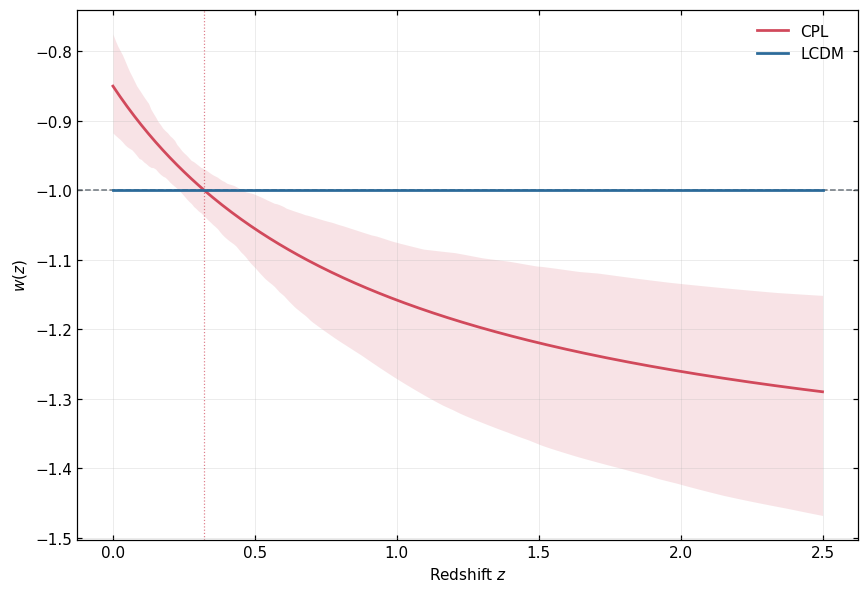

In [22]:
fig = fit.plots.compare_w_of_z(other_fits=fit_lcdm, labels=["CPL", "LCDM"])

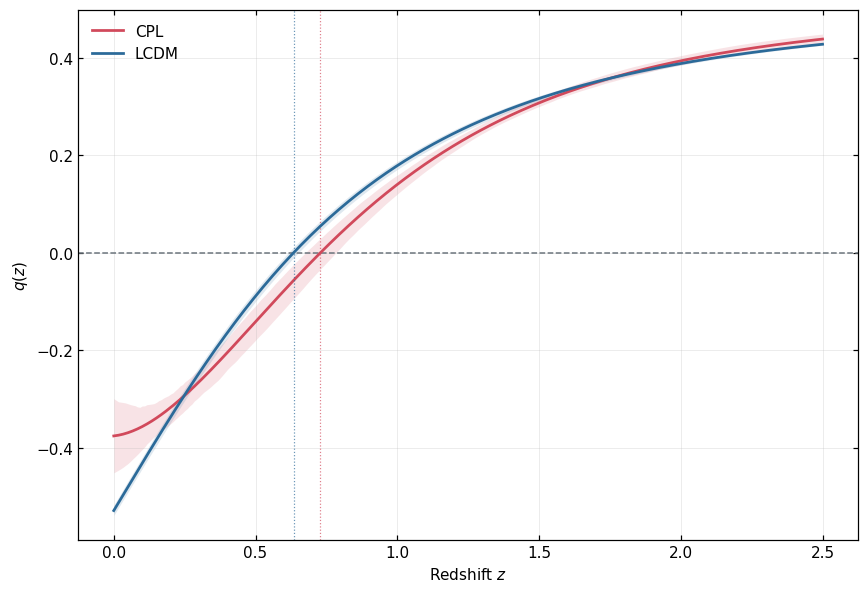

In [23]:
fig = fit.plots.compare_deceleration(other_fits=fit_lcdm, labels=["CPL", "LCDM"])

Each curve above marks its own deceleration/acceleration transition redshift $z_t$ (where $q(z_t)=0$) -- CPL's evolving $w(z)$ shifts $z_t$ relative to $\Lambda$CDM's, which is exactly the kind of difference AIC/BIC alone don't show.

## 12. How well does the fit match Planck specifically?

Planck is one of four datasets in the joint fit above, not an
independent check this time (that's `cpl_mcmc_analysis.ipynb`) -- so
instead of a separate consistency check, this is the standardized-
residual ("pull") plot for how well the best-fit CPL point matches
Planck's own 3 compressed data points ($R$, $\ell_A$,
$\omega_b h^2$) specifically, in units of Planck's own uncertainty on
each. Since `"planck"` is one of `fit`'s own datasets now,
`fit.plots.planck_residuals()` works directly.

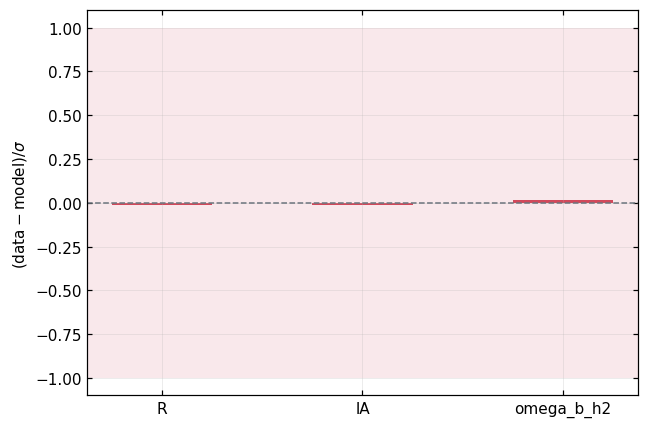

In [24]:
fig = fit.plots.planck_residuals()

## Summary

This notebook fit the CPL dark-energy model jointly to Cosmic
Chronometers, DESI BAO, Pantheon+ supernovae, and Planck's CMB distance
priors, with $r_d$ and $\Omega_b$ free (made constrainable by including
Planck) alongside $H_0$, $\Omega_m$, $w_0$, $w_a$, using a
publication-scale MCMC chain (`nwalkers=64`, `nsteps=12000`) evaluated
in parallel across every available CPU core. It checked chain
convergence, produced the standard cosmology-paper figures (Hubble
diagram, $H(z)$, BAO distances, $w(z)$ evolution, deceleration
parameter), compared CPL against flat $\Lambda$CDM (fit to the same
four datasets and free parameters bar $w_0$/$w_a$) with AIC/BIC/a
likelihood-ratio test and side-by-side comparison plots, and checked
the fit's match to Planck's own data points specifically.

If `fit.convergence()` still came back `False` at these settings,
`nsteps` needs to go higher -- rerun section 4 with a larger value (or
call `fit.run_mcmc(...)` again with more steps) and recheck.

See the [CosmoFit README](https://github.com/salihyesil59/CosmoFit) for
the full API, and `cpl_mcmc_analysis.ipynb` for the shorter,
Planck-as-independent-check variant of this analysis.